# Multilabel Classification


In multi-label classification, each sample can have multiple labels associated with it, as opposed to the traditional single-label classification where each sample can have only one label associated with it.

This means that the output of a multi-label classifier is an array of probabilities, one for each label, indicating the probability of the input sample belonging to each label.

In [ ]:
!nvidia-smi

Sun Aug 23 19:33:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%matplotlib inline

In [ ]:
! pip install -q transformers[sentencepiece] fastbook fastai nbdev plum-dispatch evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.6 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/msi1427/blurr.git
%cd blurr

Cloning into 'blurr'...
remote: Enumerating objects: 5063, done.
remote: Counting objects: 100% (894/894), done.
remote: Compressing objects: 100% (311/311), done.
remote: Total 5063 (delta 705), reused 702 (delta 576), pack-reused 4169 (from 1)
Receiving objects: 100% (5063/5063), 26.85 MiB | 15.38 MiB/s, done.
Resolving deltas: 100% (3934/3934), done.
/content/blurr


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification, AutoConfig
from fastai.text.all import *
from blurr.text.data.all import *
from blurr.text.modeling.all import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/udemy_project/Multilabel Text Classification


/content/drive/MyDrive/udemy_project/Multilabel Text Classification


#Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/udemy_project/Datasets/course_details.csv")
df.head()

,title,url,description,topic,topic_list
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']"
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']"
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']"
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']"
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Languages', 'React JS', 'React Hooks']"


In [ ]:
df.shape

(11061, 5)

In [ ]:
df = df.dropna().reset_index(drop=True)
df.shape

(11057, 5)

In [ ]:
topic_lists = df.topic_list.to_list()
topic_count = {}
for topics in topic_lists:
    topic_list = eval(topics)
    for topic in topic_list:
        if topic in topic_count.keys():
            topic_count[topic] += 1
        else:
            topic_count[topic] = 1
print(f"Number of Topics: {len(topic_count)}")
print(topic_count)

Number of Topics: 2436
{'Development': 1598, 'Programming Languages': 336, 'Python': 272, 'Web Development': 479, 'Node.Js': 38, 'MongoDB': 15, 'JavaScript': 103, 'Data Science': 243, 'Flask': 9, 'Web Scraping': 10, 'React JS': 61, 'React Hooks': 6, 'Angular': 34, 'Java': 125, 'Machine Learning': 88, 'R (programming language)': 17, 'Software Development Tools': 101, 'Prompt Engineering': 38, 'Software Testing': 160, 'Selenium WebDriver': 28, 'Automation': 50, 'CSS': 68, 'Web Design': 142, 'Responsive Design': 14, 'HTML': 54, 'OpenAI API': 9, 'ChatGPT': 198, 'Database Design & Development': 98, 'SQL': 105, 'MySQL': 33, 'Game Development': 60, 'Game Development Fundamentals': 44, '2D Game Development': 13, 'Unity': 47, 'C# (programming language)': 57, 'Mobile Development': 58, 'Swift': 10, 'Xcode': 4, 'ARKit': 2, 'iOS Development': 17, 'Spring Framework': 30, 'Spring MVC': 9, 'Hibernate': 7, 'Dart (programming language)': 8, 'Google Flutter': 9, 'Front End Web Development': 26, 'Redux Fr

In [ ]:
threshold = int(len(df) * 0.01)
rare_topics = [cat for cat, count in topic_count.items() if count < threshold]
len(rare_topics), rare_topics[:5]

(2370, ['Node.Js', 'MongoDB', 'JavaScript', 'Flask', 'Web Scraping'])

In [ ]:
topic_lists = df.topic_list.to_list()
revised_topic_list = []
indices_to_drop = []

for idx, topics in enumerate(topic_lists):
  topic_list = eval(topics)
  revised_topics = []

  for topic in topic_list:
    if topic not in rare_topics:
      revised_topics.append(topic)

  if len(revised_topics) == 0:
    indices_to_drop.append(idx)
  else:
    revised_topic_list.append(revised_topics)

df = df.drop(indices_to_drop).reset_index(drop=True)
df.shape

(11055, 5)

In [ ]:
df['revised_topics'] = revised_topic_list

In [ ]:
df.tail()

,title,url,description,topic,topic_list,revised_topics
11050,Clandestine Charisma Social Intelligence certificate course,https://www.udemy.com/course/clandestine-charisma,"Learn social intelligence spy secrets and get a custom certificate upon completion. Have you ever desired to be more suave, debonair, and dynamic, and charismatic? Do you want to be more calm, cool, and confident? Have you ever desired to be as witty and debonair as your favorite action movie super spy? Most of us don't have the luxury of a team of writers scripting our dialogue. However, the clandestine world of real life “secret agents” has the answer. HUMINT, or human intelligence is an absolutely crucial part of espionage. Operations officers must entice and recruit foreign agents and ...",Charisma,"['Personal Development', 'Influence', 'Charisma']",[Personal Development]
11051,The Ultimate Guide to ChatGPT: AI for everyday life,https://www.udemy.com/course/ultimate-guide-to-chatgpt,"Hello and welcome to ""The ultimate guide to ChatGPT: AI for everyday life!"" course on Udemy. In this course, you will learn how to harness the power of AI to make your life easier and more productive. I will start by introducing you to ChatGPT, an AI-powered language model that can generate human-like responses to prompts. Following that, I will emphasize the importance of prompts in utilizing ChatGPT effectively as they serve as the starting point for generating a response. I will then discuss ChatGPT's limitations. Next, I'll explore some of the most popular use cases of ChatGPT, such as...",ChatGPT,"['Personal Development', 'Personal Productivity', 'ChatGPT']","[Personal Development, Personal Productivity, ChatGPT]"
11052,Solve your problems at their root!,https://www.udemy.com/course/solve-your-problems-at-their-root,"If you have a persistent strong problem, its deepest possible root is the hidden loyalty to your own family history. This course will explain the background and show you the solutions. You may always have intense, stressful feelings like fear, depression, anger). Or you behave in a way that causes you difficulties and although you fight against, you have no success. These can be addictions, deliquent behaviour, being always the victim etc. Or you sabotage your goals and your happiness. The reason for this is the hidden loyalty in a family. Children absorb feelings or behaviors from former ...",Psychology,"['Personal Development', 'Personal Transformation', 'Psychology']","[Personal Development, Personal Transformation]"
11053,Master Your Voice: Public Speaking Made Easy,https://www.udemy.com/course/master-your-voice-public-speaking-made-easy,"Welcome to ""Captivate, Connect, and Convince: The Secrets of Engaging Public Speaking"" – your ultimate guide to becoming a confident and captivating speaker! In this course, you'll embark on an exciting journey to unlock the secrets of effective public speaking. Whether you're a beginner or looking to polish your skills, this course is designed to empower you with the knowledge and techniques needed to captivate any audience and deliver impactful presentations. Starting with the basics, you'll learn the importance of effective public speaking skills and how to overcome any fears standing i...",Public Speaking,"['Personal Development', 'Leadership', 'Public Speaking']","[Personal Development, Leadership]"
11054,Professional Ethics for Helping Professions,https://www.udemy.com/course/professional-ethics-for-helping-professions,"Are you a helping professional, such as a counsellor, psychotherapist, coach or teacher (mindfulness, meditation, yoga, etc)? If so, there are a set of core skills you need to keep yourself and your clients safe. This course will teach you everything you need to know about best practices and working within ethical guidelines. We’ll cover: Fairness, equality & diversity, exploring the barriers clients may encounter in using our services Building an appropriate relationship with clients and hand

In [ ]:
revised_topics_list = df.revised_topics.to_list()
revised_topic_count = {}
for topics in revised_topics_list:
  topic_list = topics
  for topic in topic_list:
    if topic in revised_topic_count.keys():
      revised_topic_count[topic] += 1
    else:
      revised_topic_count[topic] = 1
print(f"Number of Topics: {len(revised_topic_count)}")
print(revised_topic_count)

Number of Topics: 66
{'Development': 1598, 'Programming Languages': 336, 'Python': 272, 'Web Development': 479, 'Data Science': 243, 'Java': 125, 'Software Testing': 160, 'Web Design': 142, 'ChatGPT': 198, 'Software Engineering': 141, 'Generative AI (GenAI)': 185, 'Artificial Intelligence (AI)': 156, 'Data Analysis': 115, 'Leadership': 257, 'Financial Trading': 158, 'Finance Fundamentals': 143, 'Business Fundamentals': 119, 'Business Strategy': 198, 'IT Certifications': 542, 'Cybersecurity': 116, 'User Experience (UX) Design': 142, 'IT & Software': 1568, 'Management Skills': 173, 'Project Management': 247, 'Cryptocurrency': 111, 'Architectural Design': 114, 'Business': 1598, 'Business Analytics & Intelligence': 233, 'Communication': 207, 'Communication Skills': 192, 'Management': 304, 'Human Resources': 115, 'Personal Development': 1597, 'Marketing': 1583, 'Investing': 134, 'Finance & Accounting': 1586, 'Content Marketing': 158, 'Personal Productivity': 243, 'Marketing Strategy': 306, 

In [ ]:
encode_topic_types = { key: idx for idx, (key, value) in enumerate(revised_topic_count.items())}
with open("topic_types_encoded.json", "w") as fp:
  json.dump(encode_topic_types, fp)

In [ ]:
# We need this because for multilabel classification all topics have possibility to be present in the predictions
categorical_topic_list = []
revised_topics_list = df.revised_topics.to_list()

for revised_topics in revised_topics_list:
  categorical_list = [0] * len(encode_topic_types)
  for topic in revised_topics:
    topic_type_index = encode_topic_types[topic]
    categorical_list[topic_type_index] = 1
  categorical_topic_list.append(categorical_list)

categorical_topic_list[3][:23]

[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
df['topic_cat_list'] = categorical_topic_list
df.head()

,title,url,description,topic,topic_list,revised_topics,topic_cat_list
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']","[Development, Programming Languages, Python]","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']","[Development, Web Development]","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']","[Development, Programming Languages, Python, Data Science]","[1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']","[Development, Web Development]","[1, 0, 0, 1, 0, 0, 0, 

#Dataloaders and Modeling

In [ ]:
labels = list(encode_topic_types.keys())

In [ ]:
model_name = "distilroberta-base"
model_cls = AutoModelForSequenceClassification
config = AutoConfig.from_pretrained(model_name)
config.num_labels = len(labels)

hf_arch, hf_config, hf_tokenizer, hf_model = get_hf_objects(model_name, model_cls=model_cls, config=config)
hf_model.config.problem_type = "multi_label_classification"

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

In [ ]:
blocks = (TextBlock(hf_arch, hf_config, hf_tokenizer, hf_model), MultiCategoryBlock(encoded=True, vocab=labels))
dblock = DataBlock(blocks=blocks, get_x=ColReader('description'), get_y=ColReader('topic_cat_list'), splitter=RandomSplitter(valid_pct=0.1, seed=42))

In [ ]:
dls = dblock.dataloaders(df, bs=32)
torch.save(dls, "dataloaders/dls-multilabel-course-classifier.pkl")

In [ ]:
# dls = torch.load("dataloaders/dls-multilabel-book-classifier.pkl")

In [ ]:
dls.vocab

['Development', 'Programming Languages', 'Python', 'Web Development', 'Data Science', 'Java', 'Software Testing', 'Web Design', 'ChatGPT', 'Software Engineering', 'Generative AI (GenAI)', 'Artificial Intelligence (AI)', 'Data Analysis', 'Leadership', 'Financial Trading', 'Finance Fundamentals', 'Business Fundamentals', 'Business Strategy', 'IT Certifications', 'Cybersecurity', 'User Experience (UX) Design', 'IT & Software', 'Management Skills', 'Project Management', 'Cryptocurrency', 'Architectural Design', 'Business', 'Business Analytics & Intelligence', 'Communication', 'Communication Skills', 'Management', 'Human Resources', 'Personal Development', 'Marketing', 'Investing', 'Finance & Accounting', 'Content Marketing', 'Personal Productivity', 'Marketing Strategy', 'Personal Transformation', 'Adobe Photoshop', 'Accounting & Bookkeeping', 'Accounting', 'Investing & Trading', 'Career Development', 'Cryptocurrency & Blockchain', 'Digital Marketing', 'Social Media Marketing', 'Search Eng

In [ ]:
doc(accuracy_multi)

In [ ]:
model = BaseModelWrapper(hf_model)

acc_02 = partial(accuracy_multi, thresh=0.2)

learner = Learner(dls,
                  model,
                  opt_func=partial(OptimWrapper, opt=torch.optim.AdamW),
                  loss_func=BCEWithLogitsLossFlat(),
                  metrics=[acc_02],
                  cbs=[BaseModelCallback],
                  splitter=blurr_splitter
                  ).to_fp16()

#Stage-0


In [ ]:
learner.freeze()

<div></div>

SuggestedLRs(slide=0.0010000000474974513, valley=0.0002290867705596611)

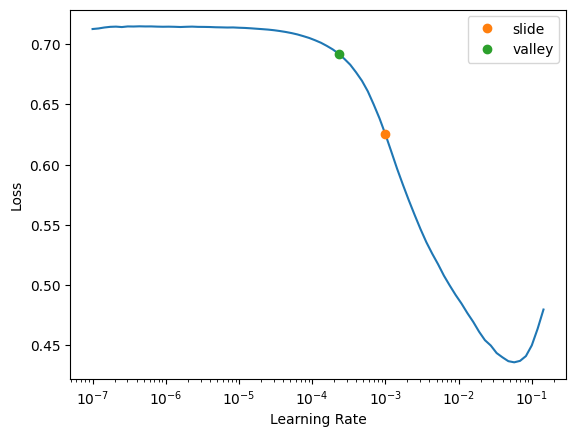

In [ ]:
learner.lr_find(suggest_funcs=[slide, valley])

In [ ]:
learner.fit_one_cycle(2, 2.3e-4)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.112056,0.093286,0.970341,01:26
1,0.077274,0.075556,0.970410,01:27


In [ ]:
learner.save("course-classifier-stage-0")

Path('models/course-classifier-stage-0.pth')

In [ ]:
learner.export("models/course-classifier-stage-0.pkl")

#Stage-1

In [ ]:
# learner.load("course-classifier-stage-0")

In [ ]:
learner.unfreeze()

<div></div>

SuggestedLRs(slide=0.0002290867705596611, valley=5.754399353463668e-06)

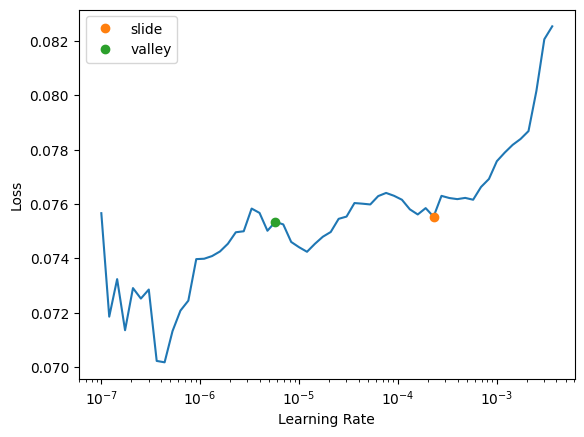

In [ ]:
learner.lr_find(suggest_funcs=[slide, valley])

In [ ]:
learner.fit_one_cycle(3, slice(1e-6, 6e-6))

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.073211,0.071348,0.969491,01:53
1,0.068256,0.068670,0.971466,01:48
2,0.068163,0.068148,0.972042,01:49


In [ ]:
learner.save("course-classifier-stage-1")

Path('models/course-classifier-stage-1.pth')

In [ ]:
learner.export("models/course-classifier-stage-1.pkl")